# Why LU Decomposition is the Preferred Method in Numerical Linear Algebra

| Date | Who | Mail |  What |
| ---  | --- | ---  | ---   |     
| Sept 11, 2026 | Diego Andrés Alvarez Marín | <daalvarez@unal.edu.co>  | Initial code created using Gemini 3.6 Flash |
| Sept 11, 2026 | Diego Andrés Alvarez Marín | <daalvarez@unal.edu.co>  | Code, formulation and comments improvements |
| Sept 23, 2026 | Diego Andrés Alvarez Marín | <daalvarez@unal.edu.co>  | Correcting error in time_perf_counter()     |

In scientific computing and data science, solving linear systems ($\boldsymbol{A}\boldsymbol{x} = \boldsymbol{b}$), finding matrix determinants ($\det(\boldsymbol{A})$), and calculating matrix inverses ($\boldsymbol{A}^{-1}$) are standard operations.

While SciPy provides high-level convenience functions like `scipy.linalg.solve`, `scipy.linalg.det`, and `scipy.linalg.inv`, using **LU Decomposition** (`scipy.linalg.lu_factor` / `scipy.linalg.lu_solve`) directly provides:

1. **Massive Speedups** when solving $\boldsymbol{A}\boldsymbol{x} = \boldsymbol{b}$ for multiple right-hand sides ($\boldsymbol{b}$).
2. **Numerical Stability & Safety** by avoiding explicitly calculating $\boldsymbol{A}^{-1}$.
3. **Prevention of Overflow/Underflow** when evaluating large matrix determinants.

In [37]:
import numpy as np
import scipy.linalg as la
import scipy
import matplotlib.pyplot as plt
import time

# Set seed for reproducibility
np.random.seed(42)

print("SciPy Version:", scipy.__version__)
print("NumPy Version:", np.__version__)

SciPy Version: 1.15.3
NumPy Version: 2.1.3


## 1. Core Concepts: Factorization Once, Reuse Many Times

When you factorize a square matrix $\boldsymbol{A}$ into $\boldsymbol{P} \cdot \boldsymbol{A} = \boldsymbol{L} \cdot \boldsymbol{U}$:
* $\boldsymbol{P}$ is a permutation matrix.
* $\boldsymbol{L}$ is lower triangular.
* $\boldsymbol{U}$ is upper triangular.

### Computational Complexity:
* **Factorization ($O(n^3)$):** Computing $\boldsymbol{L}$ and $\boldsymbol{U}$ requires $O(\frac{2}{3}n^3)$ operations.
* **Solving ($O(n^2)$):** Solving $\boldsymbol{L}\boldsymbol{y} = \boldsymbol{P}\boldsymbol{b}$ (forward substitution) and $\boldsymbol{U}\boldsymbol{x} = \boldsymbol{y}$ (back substitution) takes only $O(2n^2)$ operations.

If you have $k$ different right-hand side vectors $\boldsymbol{b}_1, \boldsymbol{b}_2, \dots, \boldsymbol{b}_k$:
- **Using `la.solve(A, b)` repeatedly:** $k \times O(n^3)$ operations.
- **Using LU Factorization once:** $O(n^3) + k \times O(n^2)$ operations.

Let's verify this mathematically and numerically!

In [38]:
# Create a random system of equations
N = 1000
A = np.random.randn(N, N)
b = np.random.randn(N)

# 1. Standard Method: la.solve
x_solve = la.solve(A, b)

# 2. LU Decomposition Method: lu_factor + lu_solve
lu, piv = la.lu_factor(A)
x_lu    = la.lu_solve((lu, piv), b)

# 3. Explicit Inverse Method (Not Recommended!)
x_inv = la.inv(A) @ b

# Check agreement
print("Difference (la.solve vs LU):      ", np.max(np.abs(x_solve - x_lu )))
print("Difference (la.solve vs Inverse): ", np.max(np.abs(x_solve - x_inv)))

Difference (la.solve vs LU):       0.0
Difference (la.solve vs Inverse):  9.166001291305292e-13


## 3. Benchmark 1: Solving $\boldsymbol{A}\boldsymbol{x}_i = \boldsymbol{b}_i$ for $k$ Right-Hand Sides

Here, we measure execution time for solving $\boldsymbol{A}\boldsymbol{x} = \boldsymbol{b}$ across multiple iterations $k=100$ on a single matrix $\boldsymbol{A}$ of varying dimension sizes $N$.

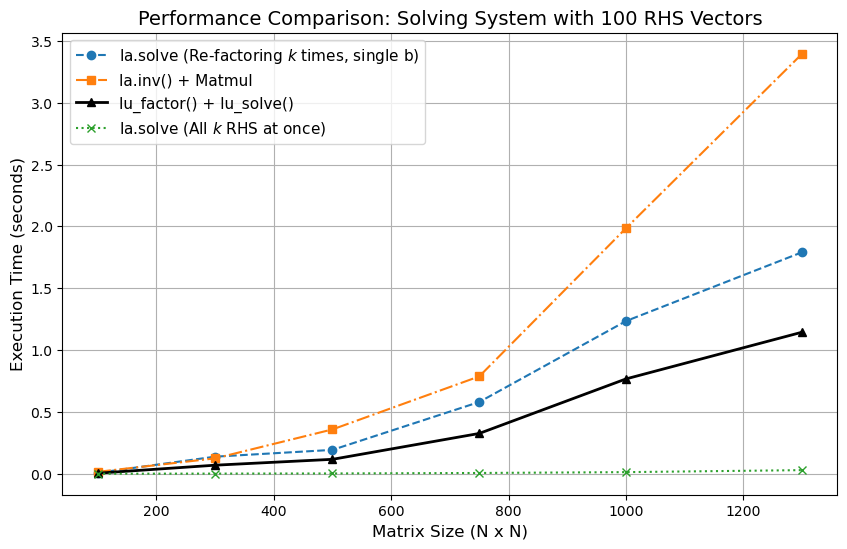

In [39]:
sizes = [100, 300, 500, 750, 1000, 1300] #, 1500 , 2000, 3000]
k_rhs = 100  # Number of different RHS vectors

time_solve       = []
time_lu          = []
time_inv         = []
time_solve_multi = []

for N in sizes:
    A = np.random.randn(N, N)

    # List of vectors
    B_list = [np.random.randn(N) for _ in range(k_rhs)]

    # Warm up, because the first call may include overhead (e.g., BLAS/LAPACK initialization)
    la.solve(A, B_list[0])
    la.inv(A)

    # Convert list of vectors to a matrix where columns are RHS
    B_matrix = np.array(B_list).T

    # Method 1: scipy.linalg.solve (Re-factors A every loop for single b)
    tic = time.perf_counter()
    for b in B_list:
        x1 = la.solve(A, b)
    toc = time.perf_counter()
    time_solve.append(toc - tic)

    # Method 2: scipy.linalg.lu_factor + lu_solve
    tic = time.perf_counter()
    #lu, piv = la.lu_factor(A)           # factorization should be done once outside the loop
    for b in B_list:
        lu, piv = la.lu_factor(A)        # this should be outside the loop to avoid repeated factorization
        x2 = la.lu_solve((lu, piv), b)
    toc = time.perf_counter()
    time_lu.append(toc - tic)

    # Method 3: scipy.linalg.inv (Computes explicit inverse)
    tic = time.perf_counter()    
    #A_inv = la.inv(A)                   # inversion should be done once outside the loop
    for b in B_list:
        A_inv = la.inv(A)                # this should be outside the loop to avoid repeated inversion
        x3 = A_inv @ b
    toc = time.perf_counter()
    time_inv.append(toc - tic)

    # --- Method 4: scipy.linalg.solve (Solving for all RHS at once) ---
    tic = time.perf_counter()
    x4 = la.solve(A, B_matrix)
    toc = time.perf_counter()
    time_solve_multi.append(toc - tic)

# Plotting Results
plt.figure(figsize=(10, 6))
plt.plot(sizes, time_solve,       'o--', label='la.solve (Re-factoring $k$ times, single b)')
plt.plot(sizes, time_inv,         's-.', label='la.inv() + Matmul')
plt.plot(sizes, time_lu,          'k^-', label='lu_factor() + lu_solve()', linewidth=2)
plt.plot(sizes, time_solve_multi, 'x:',  label='la.solve (All $k$ RHS at once)')

plt.xlabel('Matrix Size (N x N)',      fontsize=12)
plt.ylabel('Execution Time (seconds)', fontsize=12)
plt.title(f'Performance Comparison: Solving System with {k_rhs} RHS Vectors', fontsize=14)
plt.grid(True)
plt.legend(fontsize=11)
plt.show()

When you write `lu, piv = la.lu_factor(A)` and `A_inv = la.inv(A)` outside the loops, you are performing the factorization and inversion only once, which is more efficient than performing these operations multiple times within the loop. Thus, `la.solve(A, b)` may appear slower than LU factorization in some cases is due to:
* Repeated factorization: calling `la.solve(A, b)` repeatedly refactors `A`.
* LU factorization and matrix inversion is only performed once, while `la.solve(A, b)` is called multiple times.

## 4. Benchmark 2: Determinants and Safe Scale Computations

The determinant of $\boldsymbol{A} = \boldsymbol{L}\boldsymbol{U}$ is:
$$\det(\boldsymbol{A}) = \det(\boldsymbol{P})^{-1} \cdot \prod_{i=1}^N \boldsymbol{U}_{ii}$$

For large matrices ($N > 500$), computing $\det(\boldsymbol{A})$ with `scipy.linalg.det` often results in **numerical overflow (`inf`)** or **underflow (`0.0`)**. LU decomposition lets us compute the **log-determinant** safely. The functoin `np.linalg.slogdet(A)` returns the sign and log of the determinant, which is numerically stable.

In [40]:
N = 100 # 1000
A = np.random.randn(N, N)

# Direct method: scipy.linalg.det
det_direct = la.det(A)

# LU Decomposition method
lu, piv = la.lu_factor(A)
diag_U = np.diag(lu)

# Log-determinant calculation (log(|det(A)|))
log_det_abs_1 = np.sum(np.log(np.abs(diag_U)))
print(f"LU Log-Determinant ln|det(A)|: {log_det_abs_1}")

# Get the sign and logarithm of the determinant (using slogdet for robustness)
sign, log_det_abs_2 = np.linalg.slogdet(A)
print(f"Sign of determinant:           {sign}")
print(f"Log-determinant:               {log_det_abs_2}")

# Calculate the determinant from LU components
det_from_lu = sign * np.exp(log_det_abs_2)

print(f"Matrix Size:                   {N}x{N}")
print(f"Direct la.det(A) result:       {det_direct}")
print(f"LU Determinant:                {det_from_lu}")

LU Log-Determinant ln|det(A)|: 181.07910375827376
Sign of determinant:           -1.0
Log-determinant:               181.07910375827376
Matrix Size:                   100x100
Direct la.det(A) result:       -4.381830260229086e+78
LU Determinant:                -4.381830260229067e+78


## 5. Summary & Best Practices

| Task | Naive Approach | Recommended LU Approach | Why? |
| :--- | :--- | :--- | :--- |
| **Solving $\boldsymbol{A}\boldsymbol{x}=\boldsymbol{b}$ once** | `la.solve(A, b)` | `la.solve(A, b)` | Under the hood, `solve` calls LU factorization once. |
| **Solving $\boldsymbol{A}\boldsymbol{x}_i=\boldsymbol{b}_i$ for $k$ vectors** | `la.solve(A, b)` in loop | `lu, piv = la.lu_factor(A)` <br> `la.lu_solve((lu, piv), b)` | Reduces complexity from $O(k n^3)$ to $O(n^3 + k n^2)$. |
| **Computing Determinants** | `la.det(A)` | Log-sum of diagonal entries from `lu_factor` | Prevents floating-point overflow (`inf`) and underflow (`0.0`). |
| **Inverting Matrices** | `la.inv(A)` | **Avoid Inverses!** Use `lu_solve` instead. | Explicit inverses are slower and lose numerical precision. |